Judul : Klasifikasi Suara Instrumen Musik Menggunakan Feature Extraction MFCC, SVM dan Random Forest
Topik : Klasifikasi Suara Instrumen Musik

Identitas Penyusun
1. Aida Zahira (24031554106)
2. Oktavia M. Lumban Batu (24031554147)
3. Fauziah Roikhana Wardah (24031554162)

Kelas 2024E

## LOAD DATASET

In [ ]:
!pip install kagglehub

In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
import numpy as np
import librosa
import librosa.display
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

warnings.filterwarnings('ignore')

In [ ]:
path = kagglehub.dataset_download("soumendraprasad/musical-instruments-sound-dataset")
print("Path to dataset files:", path)

TRAIN_PATH = os.path.join(path, "Train_submission", "Train_submission")
TEST_PATH = os.path.join(path, "Test_submission", "Test_submission")
META_TRAIN = os.path.join(path, "Metadata_Train.csv")
META_TEST = os.path.join(path, "Metadata_Test.csv")

df_train = pd.read_csv(META_TRAIN)
df_test = pd.read_csv(META_TEST)

print("Kolom CSV train:", df_train.columns.tolist())
print(df_train.head())
print(f"\nTotal data train: {len(df_train)}")
print("Distribusi kelas train:")
print(df_train['Class'].value_counts())
print("\nDistribusi kelas test:")
print(df_test['Class'].value_counts())

Using Colab cache for faster access to the 'musical-instruments-sound-dataset' dataset.
Path to dataset files: /kaggle/input/musical-instruments-sound-dataset
Kolom CSV train: ['FileName', 'Class']
            FileName         Class
0  1-E1-Major 00.wav  Sound_Guitar
1  1-E1-Major 01.wav  Sound_Guitar
2  1-E1-Major 02.wav  Sound_Guitar
3  1-E1-Major 03.wav  Sound_Guitar
4  1-E1-Major 04.wav  Sound_Guitar

Total data train: 2629
Distribusi kelas train:
Class
Sound_Guitar    700
Sound_Drum      700
Sound_Violin    700
Sound_Piano     529
Name: count, dtype: int64

Distribusi kelas test:
Class
Sound_Guiatr    20
Sound_Drum      20
Sound_Violin    20
Sound_Piano     20
Name: count, dtype: int64


## EKSTRAKSI FITUR

In [ ]:
SR = 22050
DURATION = 3
N_MFCC = 13

def load_audio(file_path, sr=SR, duration=DURATION):
    audio, sr = librosa.load(file_path, sr=sr, duration=duration)
    target_len = sr * duration
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]
    return audio

def extract_mfcc_features(file_path):
    audio = load_audio(file_path)
    features = []

    # Ekstraksi MFCC + Delta + Delta2 (Total: 78 dimensi)
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    features.extend(np.mean(delta_mfcc, axis=1))
    features.extend(np.std(delta_mfcc, axis=1))
    features.extend(np.mean(delta2_mfcc, axis=1))
    features.extend(np.std(delta2_mfcc, axis=1))

    return np.array(features)

In [ ]:
print("Ekstraksi fitur data Train")
features_train, labels_train = [], []
gagal_train = 0

for idx, row in df_train.iterrows():
    fpath = os.path.join(TRAIN_PATH, row['FileName'])
    if not os.path.exists(fpath):
        gagal_train += 1
        continue
    try:
        feat = extract_mfcc_features(fpath)
        features_train.append(feat)
        labels_train.append(row['Class'])
    except Exception as e:
        gagal_train += 1

X_all = np.array(features_train)
y_all = np.array(labels_train)

print(f"Berhasil: {len(X_all)}, Gagal: {gagal_train}")
print(f"Shape fitur train (MFCC Only): {X_all.shape}")
print(f"Kelas: {np.unique(y_all)}")
print(f"NaN di X_all: {np.isnan(X_all).sum()}")

mfcc_cols = (
    [f'MFCC_mean_{i+1}' for i in range(N_MFCC)] +
    [f'MFCC_std_{i+1}' for i in range(N_MFCC)] +
    [f'MFCC_d_mean_{i+1}' for i in range(N_MFCC)] +
    [f'MFCC_d_std_{i+1}' for i in range(N_MFCC)] +
    [f'MFCC_d2_mean_{i+1}' for i in range(N_MFCC)] +
    [f'MFCC_d2_std_{i+1}' for i in range(N_MFCC)]
)
df_feat = pd.DataFrame(X_all, columns=mfcc_cols)

Ekstraksi fitur data Train
Berhasil: 2629, Gagal: 0
Shape fitur train (MFCC Only): (2629, 78)
Kelas: ['Sound_Drum' 'Sound_Guitar' 'Sound_Piano' 'Sound_Violin']
NaN di X_all: 0


## EDA

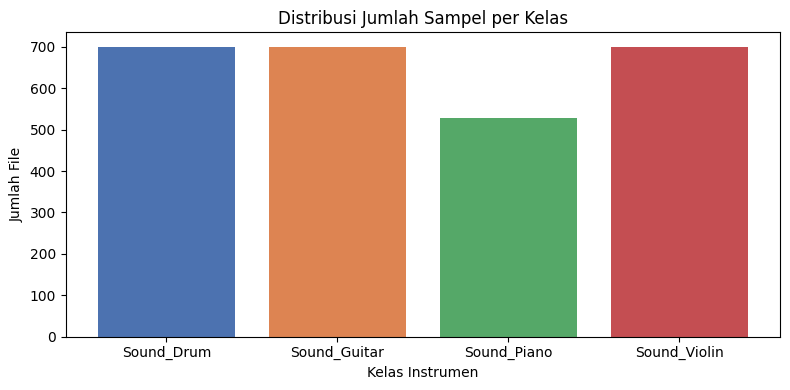

In [ ]:
# Grafik Distribusi Jumlah Sampel
plt.figure(figsize=(8, 4))
kelas, jumlah = np.unique(y_all, return_counts=True)
plt.bar(kelas, jumlah, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Distribusi Jumlah Sampel per Kelas')
plt.xlabel('Kelas Instrumen')
plt.ylabel('Jumlah File')
plt.tight_layout()
plt.show()

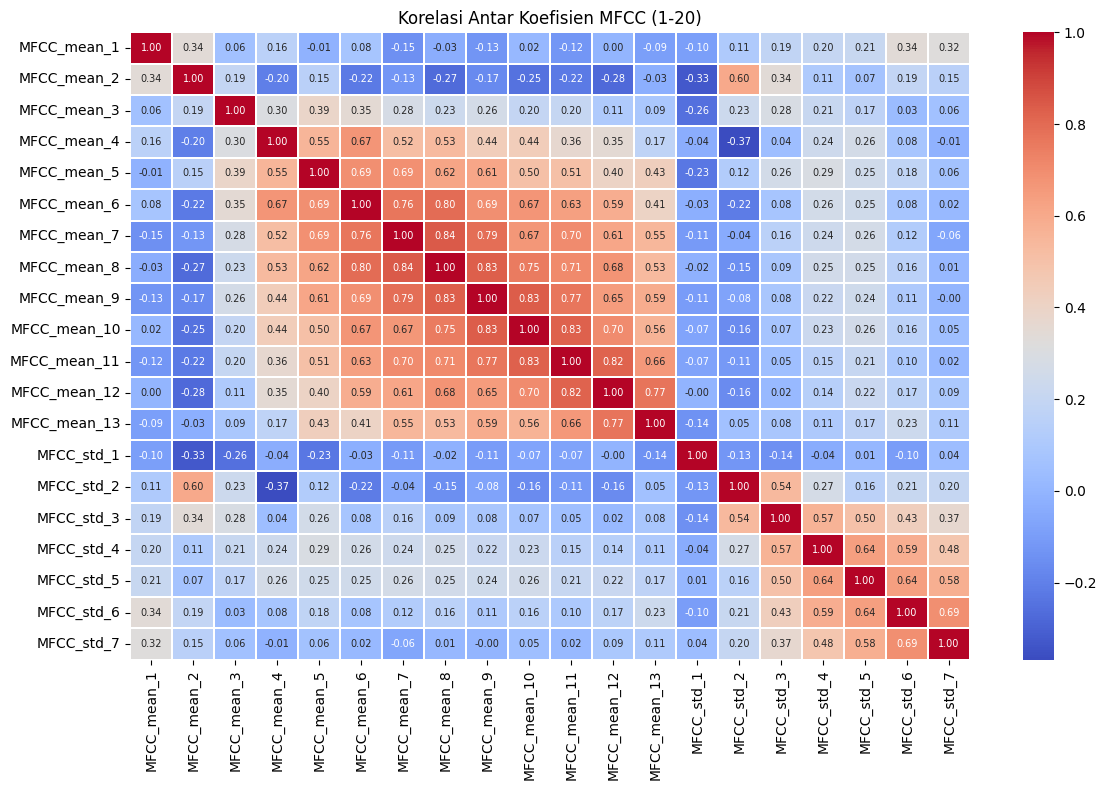

In [ ]:
# Heatmap Korelasi MFCC (20 Koefisien Pertama)
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_feat.iloc[:, :20].corr(),
    annot=True,
    fmt=".2f",
    annot_kws={'size': 7},
    cmap='coolwarm',
    linewidths=0.3
)
plt.title('Korelasi Antar Koefisien MFCC (1-20)')
plt.tight_layout()
plt.show()

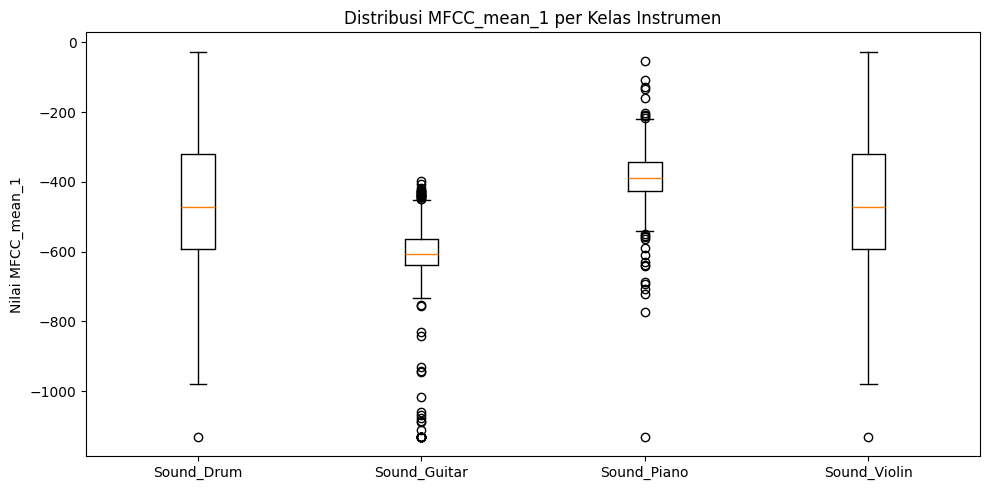

In [ ]:
# Boxplot Distribusi MFCC_mean_1 per Kelas
df_feat['label'] = y_all
plt.figure(figsize=(10, 5))

for i, kelas in enumerate(np.unique(y_all)):
    subset = df_feat[df_feat['label'] == kelas]['MFCC_mean_1']
    plt.boxplot(subset, positions=[i], labels=[kelas])

plt.title('Distribusi MFCC_mean_1 per Kelas Instrumen')
plt.ylabel('Nilai MFCC_mean_1')
plt.tight_layout()
plt.show()

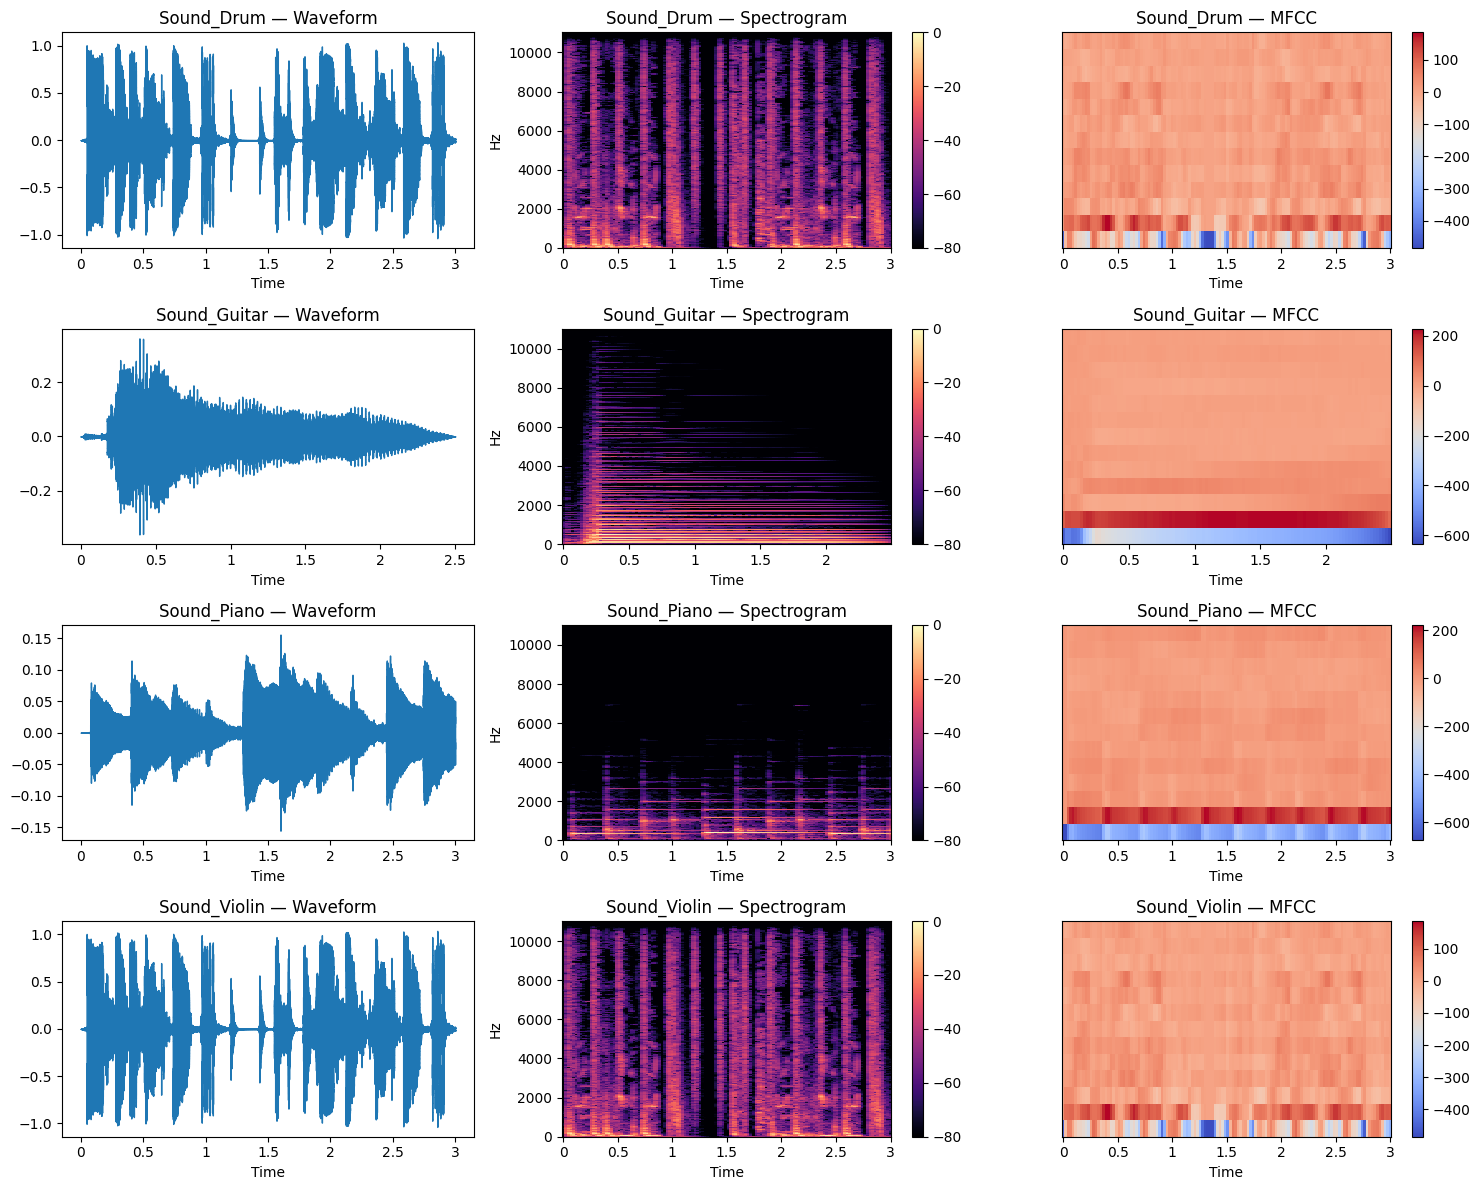

In [ ]:
# Visualisasi Isu Sinyal Per Kelas (Waveform, Spectrogram, MFCC)
unique_classes = np.unique(y_all)
fig, axes = plt.subplots(4, 3, figsize=(15, 12))

for i, kls in enumerate(unique_classes):
    sample_file = df_train[df_train['Class'] == kls]['FileName'].iloc[0]
    fpath = os.path.join(TRAIN_PATH, sample_file)
    audio, sr = librosa.load(fpath, sr=SR, duration=DURATION)

    # Waveform
    librosa.display.waveshow(audio, sr=sr, ax=axes[i][0])
    axes[i][0].set_title(f'{kls} — Waveform')

    # Spectrogram
    S = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    img = librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='hz', ax=axes[i][1])
    axes[i][1].set_title(f'{kls} — Spectrogram')
    fig.colorbar(img, ax=axes[i][1])

    # MFCC
    mfcc_ex = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
    img2 = librosa.display.specshow(mfcc_ex, x_axis='time', ax=axes[i][2])
    axes[i][2].set_title(f'{kls} — MFCC')
    fig.colorbar(img2, ax=axes[i][2])

plt.tight_layout()
plt.show()

## SPLIT & NORMALISASI DATA

In [ ]:
print("Distribusi kelas sebelum RUS:")
for kls, jml in sorted(Counter(y_all).items()):
    print(f"  {kls}: {jml} sampel")

TARGET_SAMPLES = 529
np.random.seed(42)
X_rus, y_rus = [], []

for kelas_nama in np.unique(y_all):
    idx = np.where(y_all == kelas_nama)[0]
    if len(idx) > TARGET_SAMPLES:
        idx = np.random.choice(idx, TARGET_SAMPLES, replace=False)
    X_rus.append(X_all[idx])
    y_rus.append(y_all[idx])

X_rus = np.vstack(X_rus)
y_rus = np.concatenate(y_rus)

print("\nDistribusi kelas setelah RUS:")
for kls, jml in sorted(Counter(y_rus).items()):
    print(f"  {kls}: {jml} sampel")
print(f"Shape X_rus: {X_rus.shape}")

# Encode Label
le = LabelEncoder()
y_rus_enc = le.fit_transform(y_rus)

# Split 80/20 (Train/Val)
X_train, X_val, y_train, y_val = train_test_split(
    X_rus, y_rus_enc, test_size=0.2, random_state=42, stratify=y_rus_enc
)

# Normalisasi Menggunakan MinMaxScaler
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

print(f"\nData train: {X_train_sc.shape}")
print(f"Data val  : {X_val_sc.shape}")

Distribusi kelas sebelum RUS:
  Sound_Drum: 700 sampel
  Sound_Guitar: 700 sampel
  Sound_Piano: 529 sampel
  Sound_Violin: 700 sampel

Distribusi kelas setelah RUS:
  Sound_Drum: 529 sampel
  Sound_Guitar: 529 sampel
  Sound_Piano: 529 sampel
  Sound_Violin: 529 sampel
Shape X_rus: (2116, 78)

Data train: (1692, 78)
Data val  : (424, 78)


## PEMBANGUNAN MODEL

In [ ]:
# SVM (RBF)
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_model.fit(X_train_sc, y_train)
y_pred_svm = svm_model.predict(X_val_sc)

# Random Forest (100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sc, y_train)
y_pred_rf = rf_model.predict(X_val_sc)

print("Model selesai dilatih dengan Fitur MFCC.")

Model selesai dilatih dengan Fitur MFCC.


## EVALUASI

In [ ]:
def evaluasi(nama, y_true, y_pred):
    print(f"\n {nama} ")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

# Tampilkan Evaluasi Data Validasi
evaluasi("SVM (RBF Kernel) - Validation Set", y_val, y_pred_svm)
evaluasi("Random Forest - Validation Set", y_val, y_pred_rf)


 SVM (RBF Kernel) - Validation Set 
Accuracy  : 0.6415
Precision : 0.6382
Recall    : 0.6415
F1-Score  : 0.6397

Classification Report:
              precision    recall  f1-score   support

  Sound_Drum       0.30      0.28      0.29       106
Sound_Guitar       0.96      0.99      0.98       106
 Sound_Piano       0.97      0.96      0.97       106
Sound_Violin       0.32      0.33      0.32       106

    accuracy                           0.64       424
   macro avg       0.64      0.64      0.64       424
weighted avg       0.64      0.64      0.64       424


 Random Forest - Validation Set 
Accuracy  : 0.5896
Precision : 0.5808
Recall    : 0.5896
F1-Score  : 0.5850

Classification Report:
              precision    recall  f1-score   support

  Sound_Drum       0.23      0.24      0.23       106
Sound_Guitar       0.94      0.98      0.96       106
 Sound_Piano       0.95      0.95      0.95       106
Sound_Violin       0.20      0.19      0.20       106

    accuracy          

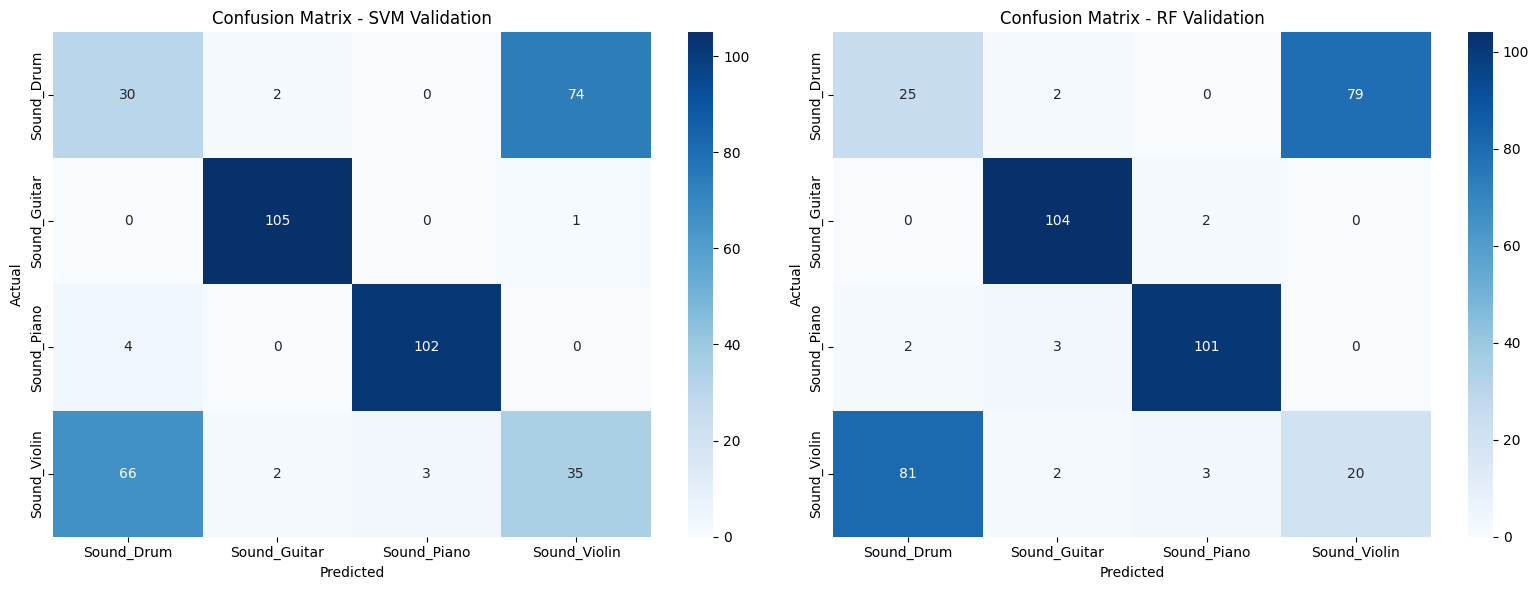

In [ ]:
# Visualisasi Confusion Matrix Data Validasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for (y_true, y_pred, title, ax) in [
    (y_val, y_pred_svm, "SVM Validation", axes[0]),
    (y_val, y_pred_rf, "RF Validation", axes[1])
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'Confusion Matrix - {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
print("Ekstraksi fitur data TEST")
features_test, labels_test = [], []
gagal_test = 0

for idx, row in df_test.iterrows():
    fpath = os.path.join(TEST_PATH, row['FileName'])
    if not os.path.exists(fpath):
        gagal_test += 1
        continue
    try:
        feat = extract_mfcc_features(fpath)
        features_test.append(feat)
        labels_test.append(row['Class'])
    except Exception as e:
        gagal_test += 1

X_test = np.array(features_test)
y_test = np.array(labels_test)
print(f"Berhasil: {len(X_test)}, Gagal: {gagal_test}")

# Perbaikan Typo Label
y_test = np.where(y_test == 'Sound_Guiatr', 'Sound_Guitar', y_test)

# Encode dan Scale data test
y_test_enc = le.transform(y_test)
X_test_sc = scaler.transform(X_test)

# Prediksi data test
y_pred_svm_test = svm_model.predict(X_test_sc)
y_pred_rf_test = rf_model.predict(X_test_sc)

# Laporan Akhir Evaluasi Data Test
evaluasi("SVM - Test Set", y_test_enc, y_pred_svm_test)
evaluasi("Random Forest - Test Set", y_test_enc, y_pred_rf_test)

Ekstraksi fitur data TEST
Berhasil: 80, Gagal: 0

 SVM - Test Set 
Accuracy  : 0.5750
Precision : 0.5677
Recall    : 0.5750
F1-Score  : 0.5403

Classification Report:
              precision    recall  f1-score   support

  Sound_Drum       0.58      0.70      0.64        20
Sound_Guitar       0.92      0.60      0.73        20
 Sound_Piano       0.51      0.90      0.65        20
Sound_Violin       0.25      0.10      0.14        20

    accuracy                           0.57        80
   macro avg       0.57      0.57      0.54        80
weighted avg       0.57      0.57      0.54        80


 Random Forest - Test Set 
Accuracy  : 0.4750
Precision : 0.4184
Recall    : 0.4750
F1-Score  : 0.4200

Classification Report:
              precision    recall  f1-score   support

  Sound_Drum       0.55      0.30      0.39        20
Sound_Guitar       0.67      0.70      0.68        20
 Sound_Piano       0.46      0.90      0.61        20
Sound_Violin       0.00      0.00      0.00        20